In [191]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import numpy as np
from scipy.stats import hypergeom
from scipy.stats import binom
from scipy.stats import multinomial
from scipy.stats import poisson

import matplotlib.pyplot as plt

(np.float64(7.0),
 array([7, 6, 3, ..., 6, 4, 4]),
 array([False, False, False, ..., False, False, False]),
 np.float64(0.09023))

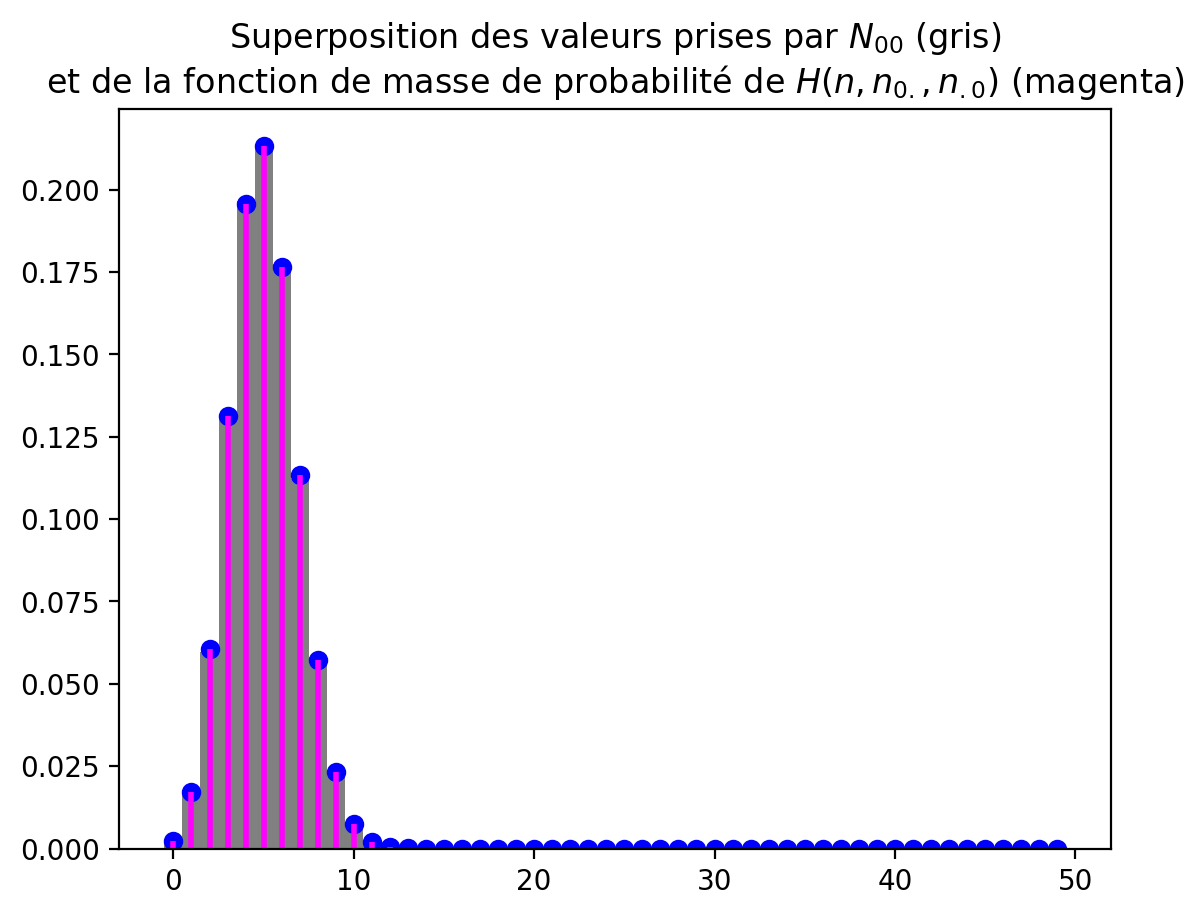

In [192]:
def conditionnal_test_under_null(alpha,n,n0_,n_0,B,plot=True):
    loi= hypergeom(n, n0_,n_0)
    crit=loi.ppf(1-alpha)
    tirages=loi.rvs(size=B)
    res=tirages>crit
    if plot:
        k = np.arange(0,max(n0_,n_0))
        pk = loi.pmf(k)
        plt.hist(tirages,density=True,bins=np.arange(min(k),max(k)+2)-0.5,histtype='bar',color="grey")
        plt.plot(k, pk, 'bo')
        plt.vlines(k, 0, pk, lw=2,color="magenta")
    plt.title("Superposition des valeurs prises par $N_{00}$ (gris)\n"
              "et de la fonction de masse de probabilité de $H(n,n_{0.},n_{.0})$ (magenta)")    
    return(crit,tirages,res,(1/B)*sum(res))
            
conditionnal_test_under_null(0.1,200,20,50,100000)

      
        

[[0.00e+00 1.00e+01 2.00e+01 3.00e+01 4.00e+01 5.00e+01 6.00e+01 7.00e+01
  8.00e+01 9.00e+01]
 [0.00e+00 1.79e-02 3.31e-02 3.84e-02 3.31e-02 3.22e-02 2.81e-02 4.36e-02
  3.22e-02 2.23e-02]]
Object `axline` not found.


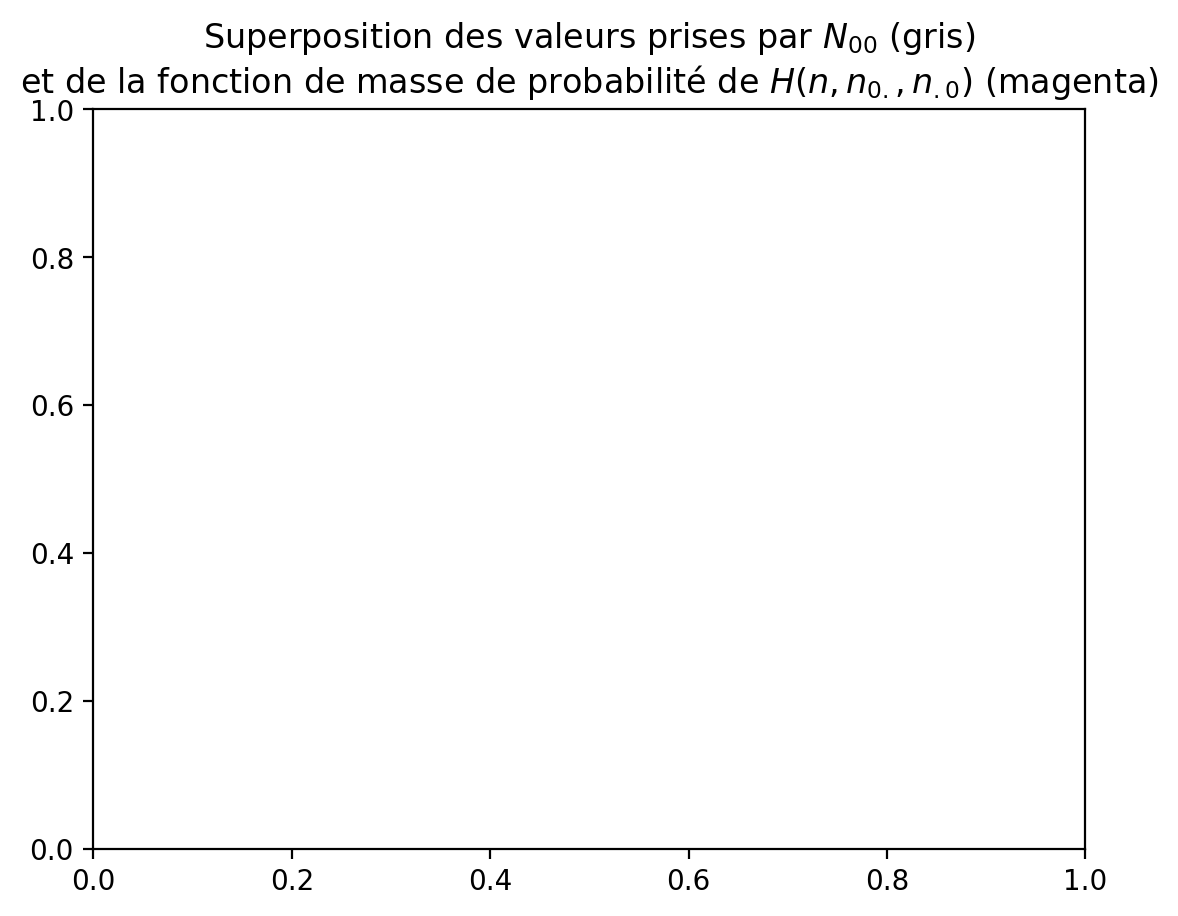

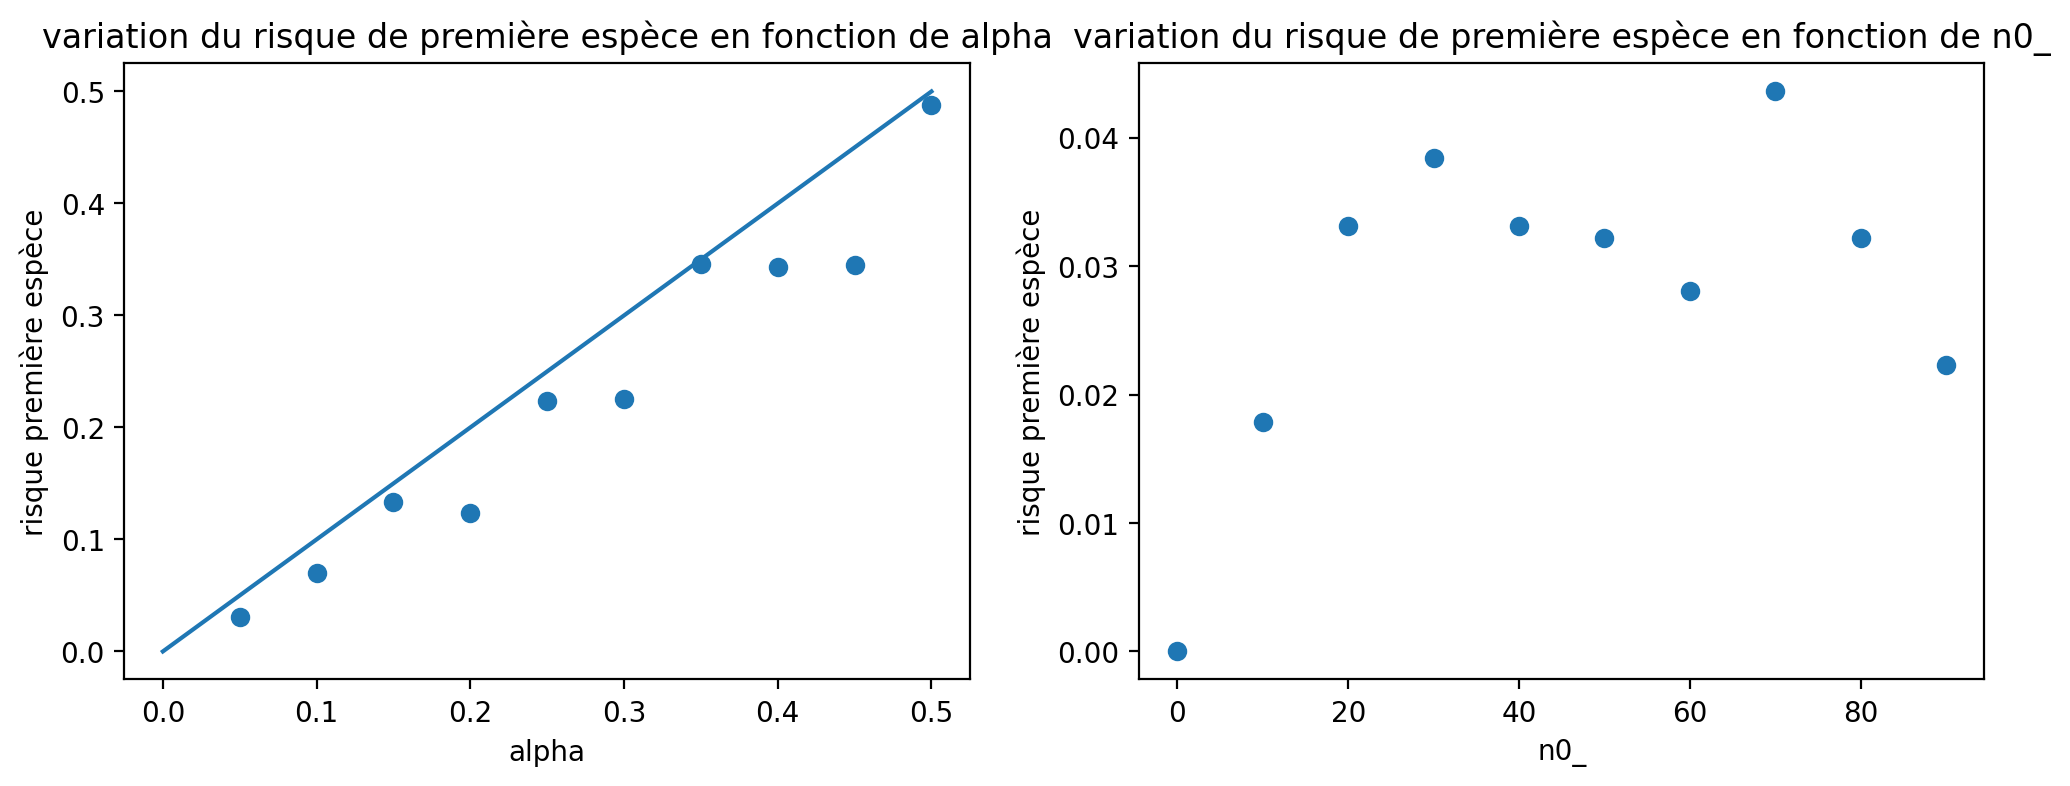

In [193]:
def variation_risque_première_espèce(alpha,n,n0_,n_0,B):
    tab=np.zeros((2,10))
    tab1=np.zeros((2,10))
    N0_=np.arange(0,100,10)
    tab1[0,:]=N0_
    alpha1=alpha
    for i in range(10):    
        tab[0,i] = alpha1      
        tab[1,i] = conditionnal_test_under_null(alpha1,n,n0_,n_0,B,plot=False)[3]     
        alpha1 += 0.05
    for j in range(10):
        tab1[1,j]=conditionnal_test_under_null(alpha,n,N0_[j],n_0,B,plot=False)[3]
        
        
    
    y=np.linspace(0,0.5,100)
    fig=plt.figure(figsize=(12,4))
    ax1=fig.add_subplot(1,2,1)
    ax2=fig.add_subplot(1,2,2)
    ax1.scatter(tab[0,:],tab[1,:])
    ax1.plot(y,y)
    ax1.set_title("variation du risque de première espèce en fonction de alpha")
    ax1.set_xlabel("alpha")
    ax1.set_ylabel("risque première espèce")
    ax2.scatter(tab1[0,:],tab1[1,:])
    ax2.set_title("variation du risque de première espèce en fonction de n0_")
    ax2.set_xlabel("n0_")
    ax2.set_ylabel("risque première espèce")
    print(tab1)


variation_risque_première_espèce(0.05,200,50,50,10000)    
?axline

In [194]:
def unconditionnal_test(alpha,n,P,B):
    tirage = multinomial.rvs(n, P, size=B)
    N0_=tirage[:,0]+tirage[:,1]
    N_0=tirage[:,0]+tirage[:,2]
    loi= hypergeom(n, N0_,N_0)
    crit=loi.ppf(1-alpha)
    res=tirage[:,0]>crit
    return ((1/B)*np.sum(res))
    
            
        
unconditionnal_test(0.05,100,np.array([0.4,0.3,0.2,0.1]),1000)


np.float64(0.004)

In [195]:
loi= hypergeom(10, 5,3)
crit=loi.ppf(1)
print(crit)

3.0


In [196]:
PX0=0.3
PX1=1-PX0
PY0=0.2
PY1=1-PY0
P=np.array([PX0*PY0,PX0*PY1,PX1*PY0,PX1*PY1])
def variation_risque_rejet(alpha,n,P,B):
    tab=np.zeros((2,20))
    tab1=np.zeros((2,20,4))
    N0_=np.arange(0,100,10)
    for i in range(10):    
        tab[0,i] = alpha      
        tab[1,i] = unconditionnal_test(alpha,n,P,B)[1]     
        alpha += 0.05
    fig=plt.figure(figsize=(12,4))
    ax1=fig.add_subplot(1,2,1)
    ax2=fig.add_subplot(1,2,2)
    ax1.scatter(tab[0,:],tab[1,:])
    ax1.set_title("variation du risque de rejet en fonction de alpha")
    ax1.set_xlabel("alpha")
    ax1.set_ylabel("risque première espèce")
    """"
    P=np.array([0.25,0.25,0.25,0.25])
    for j in range(20):
        tab1[0,j]=P+np.array([0.01,-0.01,0,0])
        tab1[1,j]=np.array([unconditionnal_test(alpha,n,tab1[0,i],B)[1],0,0,0])
        P=tab1[0,j]
    ax2.scatter(tab1[0,:,0], tab1[1,:,0])
    ax2.set_title("variation du risque de rejet en fonction de alpha")
    ax1.set_xlabel("alpha")
    ax1.set_ylabel("risque première espèce")
    
       """ 
        
    

    




In [197]:
PX0=0.4
PX1=1-PX0
PY0=0.8
PY1=1-PY0
P=np.array([PX0*PY0,PX0*PY1,PX1*PY0,PX1*PY1])
variation_risque_rejet(0.05,100,P,1000)

IndexError: invalid index to scalar variable.

(np.float64(56.0),
 array([56, 48, 48, ..., 52, 48, 56]),
 array([False, False, False, ..., False, False, False]),
 np.float64(0.0949))

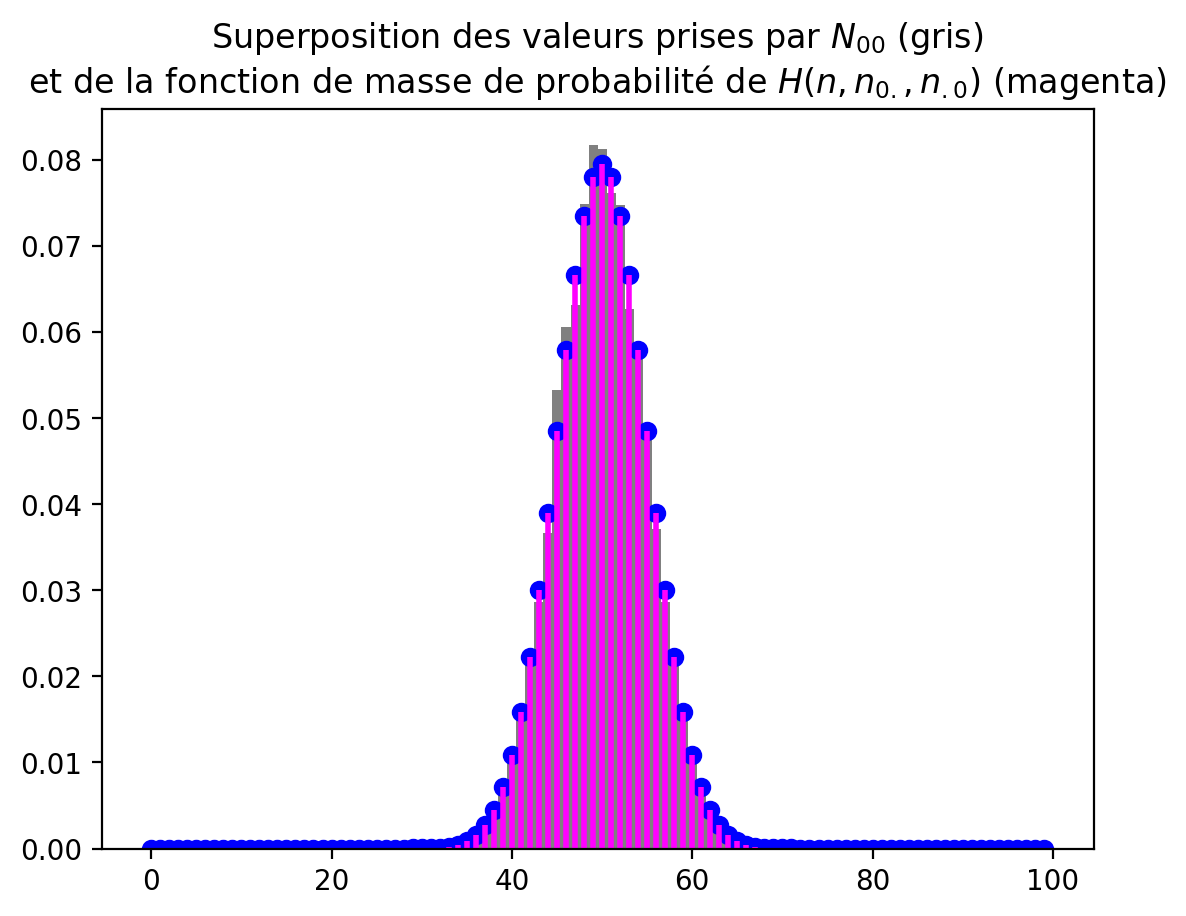

In [198]:
def conditionnal_binom_test_under_null(alpha,n,B,plot=True):
    loi= binom(n,1/2)
    crit=loi.ppf(1-alpha)
    tirages=loi.rvs(size=B)
    res=np.ones(len(tirages))
    res=tirages>crit
    if plot:
        k = np.arange(0,n)
        pk = loi.pmf(k)
        plt.hist(tirages,density=True,bins=np.arange(min(k),max(k)+2)-0.5,histtype='bar',color="grey")
        plt.plot(k, pk, 'bo')
        plt.vlines(k, 0, pk, lw=2,color="magenta")
    plt.title("Superposition des valeurs prises par $N_{00}$ (gris)\n"
              "et de la fonction de masse de probabilité de $H(n,n_{0.},n_{.0})$ (magenta)")    
    return(crit,tirages,res,(1/B)*sum(res))
            
conditionnal_binom_test_under_null(0.1,100,10000)

      
        

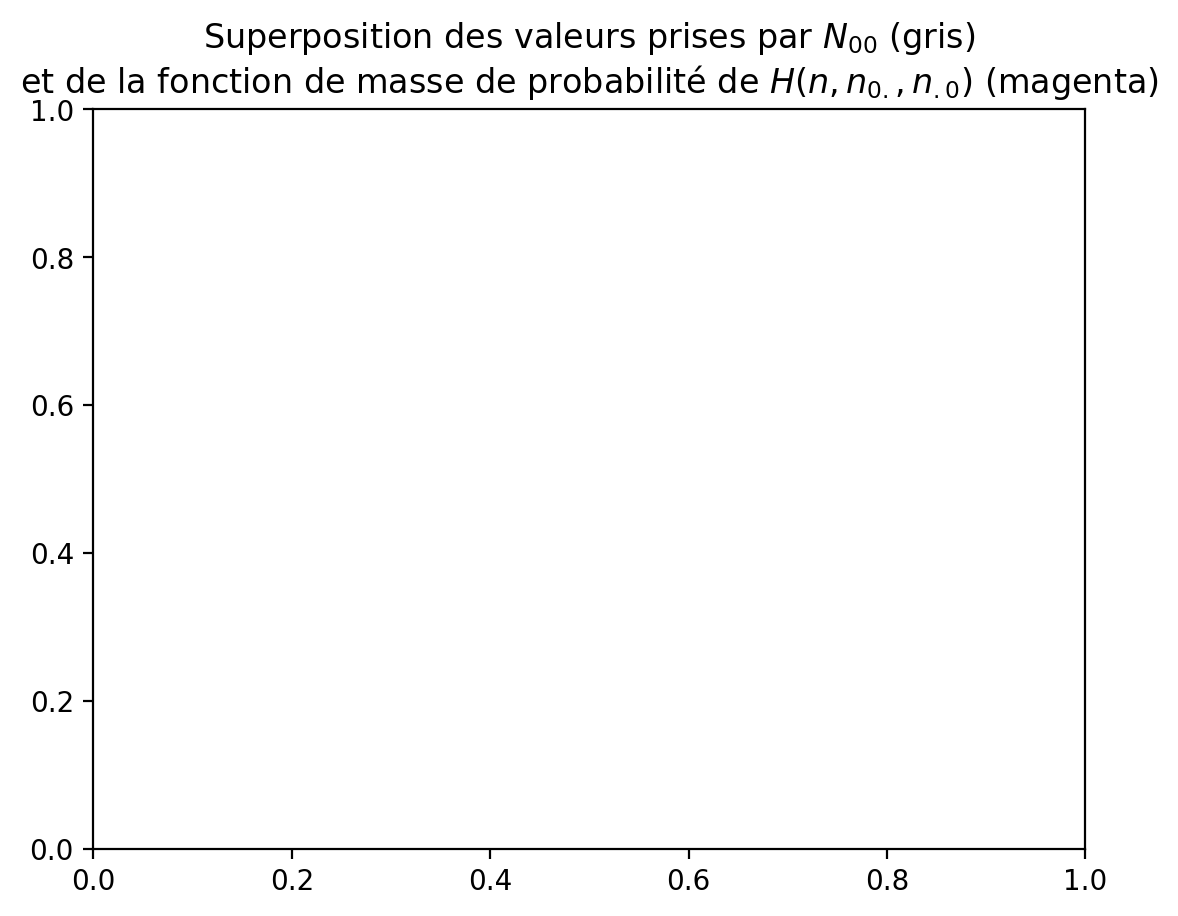

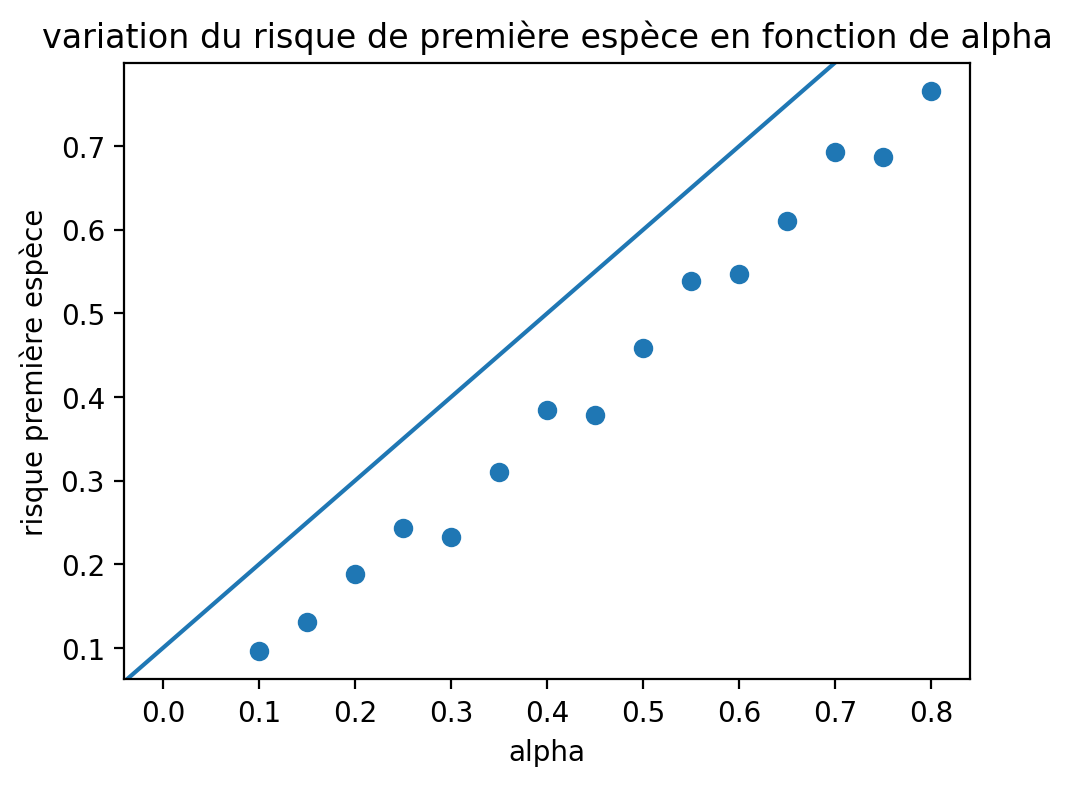

In [199]:
def variation_binom_risque_première_espèce(alpha,n,B):
    tab=np.zeros((2,15))
    
    
    
    alpha1=alpha
    for i in range(15):    
        tab[0,i] = alpha1      
        tab[1,i] = conditionnal_binom_test_under_null(alpha1,n,B,plot=False)[3]     
        alpha1 += 0.05
        
    y=np.linspace(0,0.5,100)
    fig=plt.figure(figsize=(12,4))
    ax1=fig.add_subplot(1,2,1)
    
    ax1.scatter(tab[0,:],tab[1,:])
    ax1.axline((0,0.1),slope=1)
    ax1.set_title("variation du risque de première espèce en fonction de alpha")
    ax1.set_xlabel("alpha")
    ax1.set_ylabel("risque première espèce")
    


variation_binom_risque_première_espèce(0.1,100,10000)    


In [218]:
def unconditionnal_binom_test(alpha,lambda1,lambda2,B):
    tirageY1 = poisson.rvs(lambda1, size=B)
    tirageY2 = poisson.rvs(lambda2, size=B)
    summ=tirageY1+tirageY2
    loi= binom(summ, 1/2)
    crit=loi.ppf(1-alpha)
    res=tirageY1>crit
    return ((1/B)*np.sum(res))
    
            
        
unconditionnal_binom_test(0.05,15,10,1000)

np.float64(0.241)

In [223]:
def variation_binom(alpha,lambda1,lambda2,B):    
    tab=np.zeros((2,20))
    for i in range(10):    
        tab[0,i] = alpha      
        tab[1,i] = unconditionnal_binom_test(alpha,lambda1,lambda2,B)     
        alpha += 0.05
    fig=plt.figure(figsize=(12,4))
    ax1=fig.add_subplot(1,2,1)
    ax1.scatter(tab[0,:],tab[1,:])
    ax1.set_title("variation du risque de rejet en fonction de alpha")
    ax1.set_xlabel("alpha")
    ax1.set_ylabel("risque première espèce")

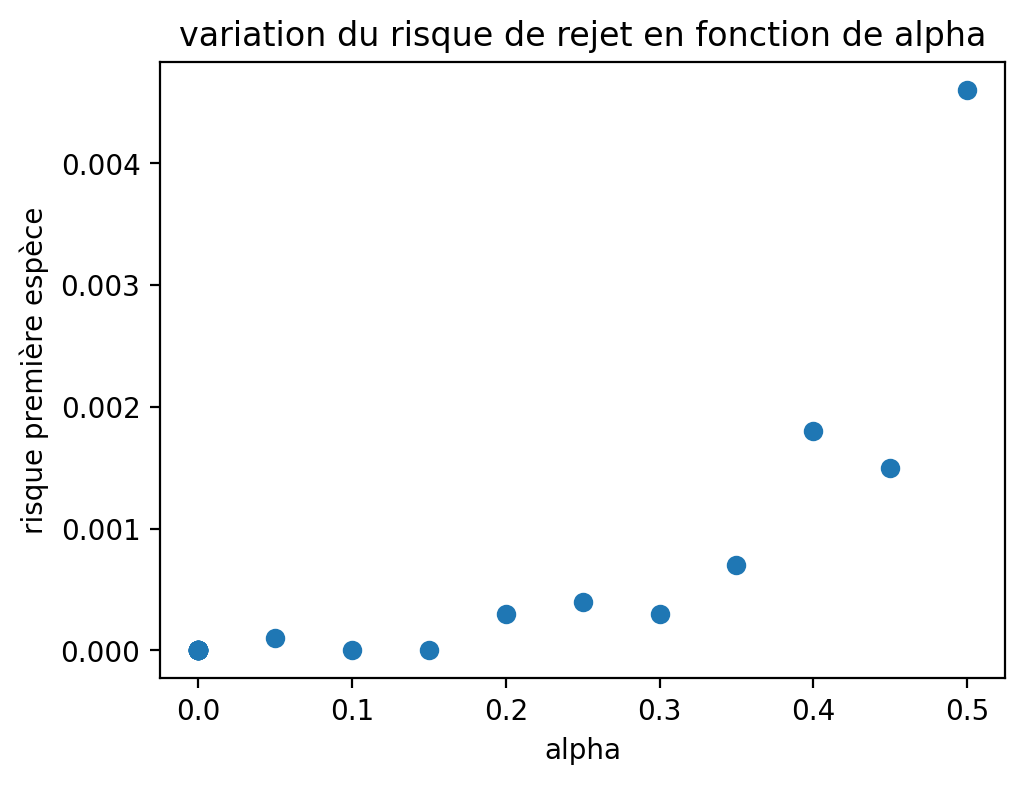

In [224]:
variation_binom(0.05,2,10,10000)